Loaded 19,618 rows × 60 columns
Plotting 53 panels: 53 cluster (green), 0 other (grey)
Grid: 14×4


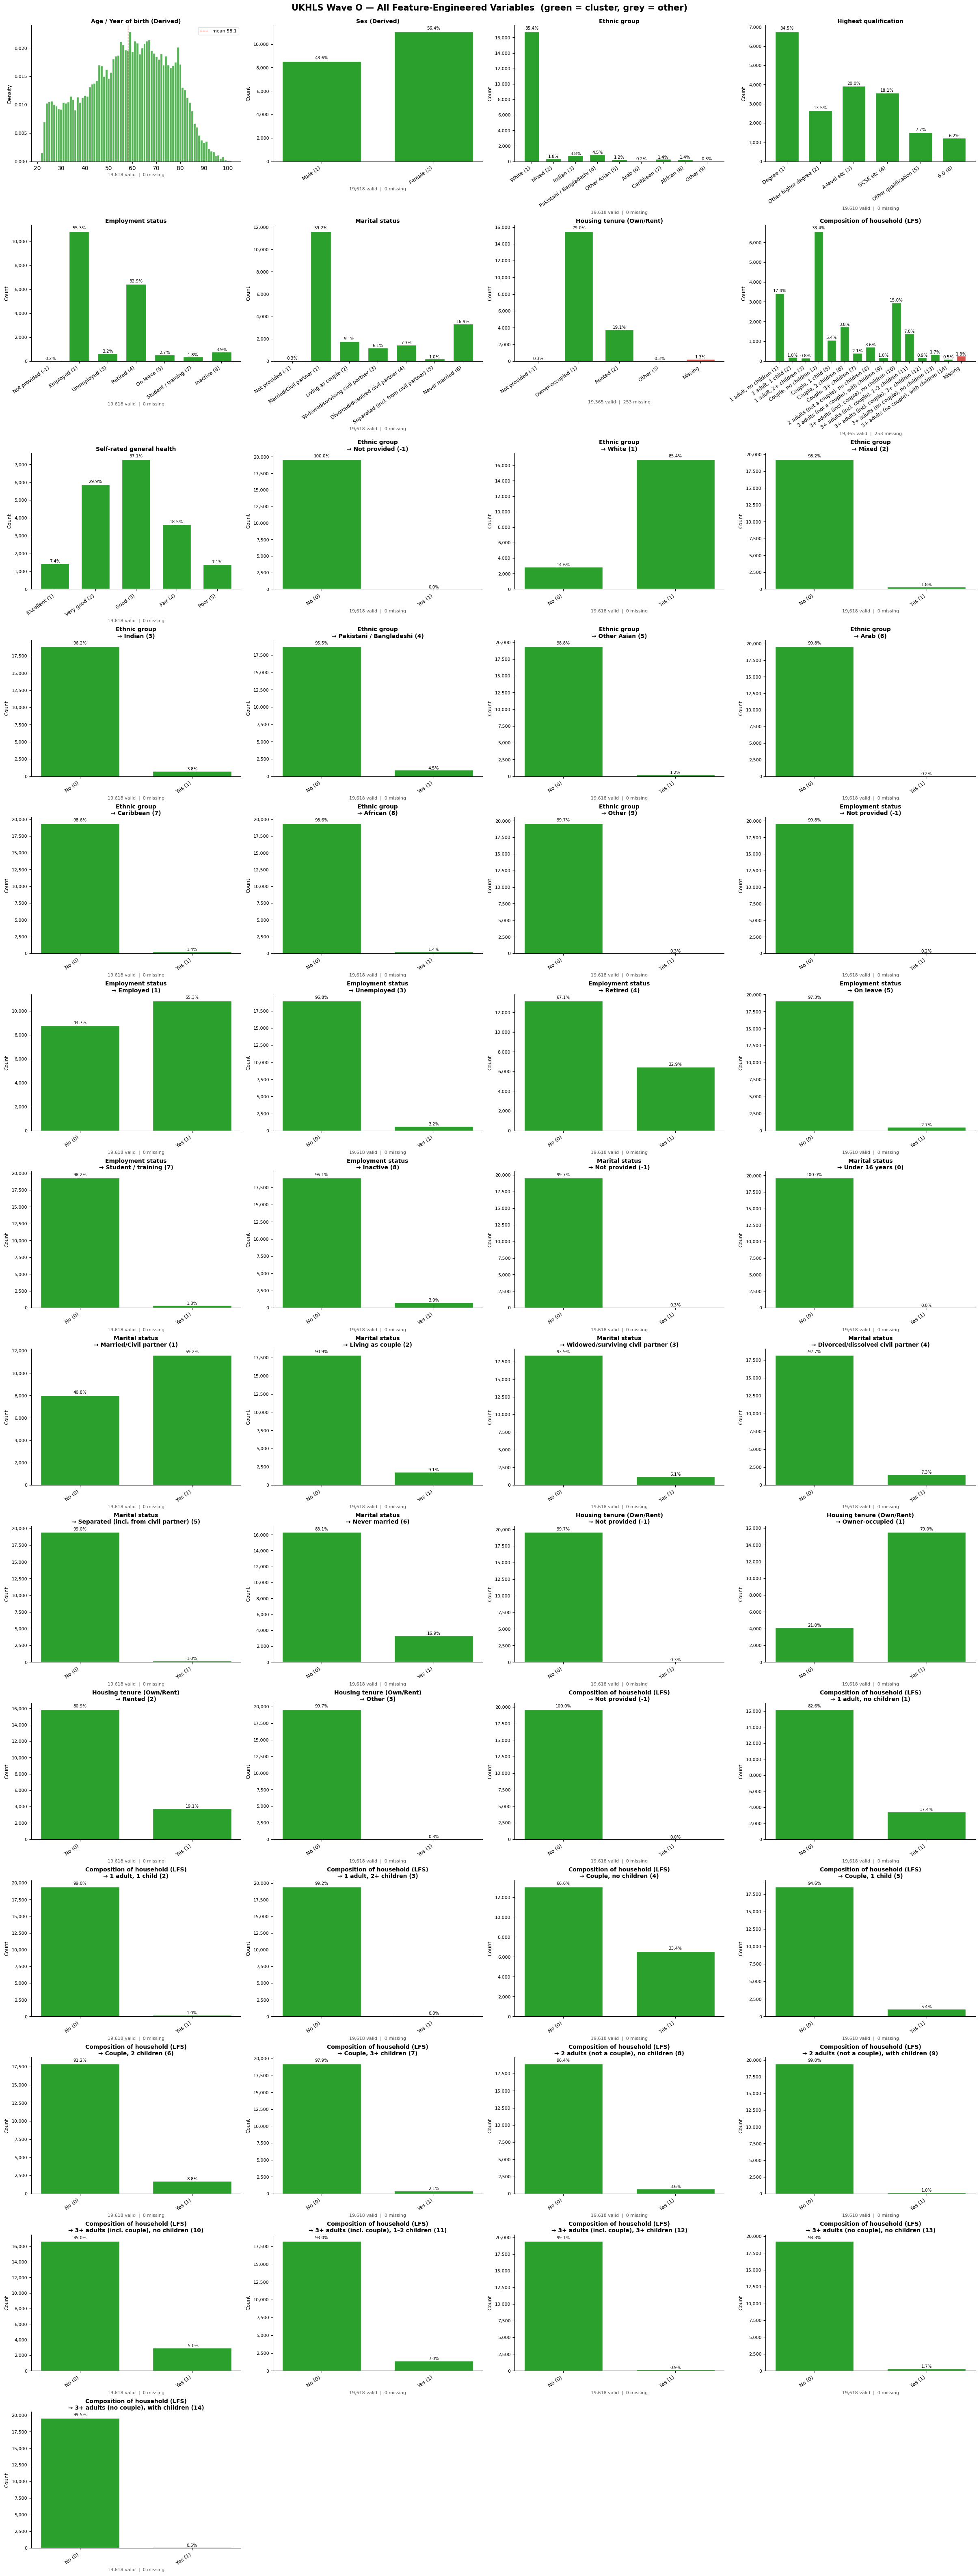

Saved to ./4c_feature_eng_visualisation.png


In [4]:
# 4b_visualise_feature_eng.ipynb
#
# Plots every variable after feature engineering.
# Also shows every OHE output column (e.g. o_jbstat_1, o_englang_1, o_jbpl_1).
# Use this to validate 4a_feature_eng_ukhls.ipynb output.
#
# Colour key:
#   green  — cluster variables (used as K-Means features)
#   grey   — non-cluster variables (present in pickle but excluded from K-Means)

import sys, os
sys.path.insert(0, os.path.abspath('..'))

import importlib
import data_pipeline.config_variables as _ukhls_vars
importlib.reload(_ukhls_vars)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from data_pipeline.config_variables import (
    VARIABLES, CLUSTER_VARS, CATEGORICAL_VARS, CATEGORY_MAPS, ONE_HOT_VARS,
    )

# ── Config ────────────────────────────────────────────────────────────────────
WAVE           = "o"
PICKLE_PATH    = "../data/4_feature_eng_ukhls/o_indresp_feature_eng.pkl"
COLS_PER_ROW   = 4
CLUSTER_COLOR  = "#2ca02c"   # green  — cluster features
OTHER_COLOR    = "#7f7f7f"   # grey   — non-cluster vars present in pickle
MISSING_COLOR  = "#d9534f"   # red    — missing-value bars

# ── Load ─────────────────────────────────────────────────────────────────────
if not os.path.exists(PICKLE_PATH):
    raise FileNotFoundError(f"{PICKLE_PATH} not found — run 4a_feature_eng_ukhls.ipynb first.")

df = pd.read_pickle(PICKLE_PATH)
print(f"Loaded {len(df):,} rows × {len(df.columns)} columns")

_cluster_set = set(CLUSTER_VARS)

# ── Build plot specs ──────────────────────────────────────────────────────────
# Section 1: all base variables
plot_specs = []
for base_code, var_def in VARIABLES.items():
    col = f"{WAVE}_{base_code}"
    if col not in df.columns:
        continue
    is_cluster = base_code in _cluster_set
    plot_specs.append(dict(
        col        = col,
        label      = var_def.get("label", base_code),
        is_cat     = var_def.get("categorical", False),
        categories = CATEGORY_MAPS.get(base_code) or var_def.get("categories"),
        bin_width  = var_def.get("bin_width"),
        bar_color  = CLUSTER_COLOR if is_cluster else OTHER_COLOR,
    ))

# Section 2: OHE output columns that exist in the dataframe
for base_code, one_hot_spec in ONE_HOT_VARS.items():
    var_def = VARIABLES.get(base_code, {})
    cat_map = CATEGORY_MAPS.get(base_code) or var_def.get("categories") or {}

    codes = list((var_def.get("group_labels") or var_def.get("categories", {})).keys()) if one_hot_spec is True else list(one_hot_spec)
    is_cluster = base_code in _cluster_set
    for code in codes:
        ohe_col = f"{WAVE}_{base_code}_{int(code)}"
        if ohe_col not in df.columns:
            continue
        code_label = cat_map.get(float(code), str(int(code)))
        code_int = int(code) if float(code) == int(code) else code
        plot_specs.append(dict(
            col          = ohe_col,
            label        = f"{var_def.get('label', base_code)}\n→ {code_label} ({code_int})",
            is_cat       = True,
            categories   = {1.0: "Yes", 0.0: "No"},
            bin_width    = None,
            bar_color    = CLUSTER_COLOR if is_cluster else OTHER_COLOR,
            is_ohe_dummy = True,
        ))

n_plots   = len(plot_specs)
n_cols    = COLS_PER_ROW
n_rows    = (n_plots + n_cols - 1) // n_cols
n_cluster = sum(1 for s in plot_specs if s["bar_color"] == CLUSTER_COLOR)
n_other   = sum(1 for s in plot_specs if s["bar_color"] == OTHER_COLOR)
print(f"Plotting {n_plots} panels: {n_cluster} cluster (green), {n_other} other (grey)")
print(f"Grid: {n_rows}×{n_cols}")

fig, axes = plt.subplots(n_rows, n_cols, figsize=(6*n_cols, 4.5*n_rows), constrained_layout=True)
axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

for idx, spec in enumerate(plot_specs):
    ax        = axes_flat[idx]
    col       = spec["col"]
    data      = df[col]
    bar_color = spec["bar_color"]

    n_valid   = int(data.notna().sum())
    n_missing = int(data.isna().sum())
    subtitle  = f"{n_valid:,} valid  |  {n_missing:,} missing"

    if spec["is_cat"] or (data.nunique(dropna=True) <= 12 and spec["categories"] is not None):
        cat_map = spec["categories"] or {}
        if spec.get("is_ohe_dummy"):
            # Binary 0/1 dummies: always show both bars (one may be 0) so 100% one-way panels look sane.
            num = pd.to_numeric(data, errors="coerce")
            c0 = int((num == 0).sum())
            c1 = int((num == 1).sum())
            nan_cnt = int(num.isna().sum())
            ordered = [(0.0, c0), (1.0, c1)]
            if nan_cnt:
                ordered.append((np.nan, nan_cnt))
        else:
            raw = data.value_counts(dropna=False).sort_index(na_position="last")
            ordered = list(raw.items())
        labels_x, counts_y, colors = [], [], []
        for rv, cnt in ordered:
            if pd.isna(rv):
                labels_x.append("Missing"); colors.append(MISSING_COLOR)
            else:
                lbl = cat_map.get(float(rv), str(rv))
                code_int = int(rv) if float(rv) == int(rv) else rv
                labels_x.append(f"{lbl} ({code_int})"); colors.append(bar_color)
            counts_y.append(cnt)
        bars  = ax.bar(range(len(labels_x)), counts_y, color=colors, edgecolor="white", width=0.7)
        total = sum(counts_y)
        ax.set_xticks(range(len(labels_x)))
        ax.set_xticklabels(labels_x, rotation=35, ha="right", fontsize=9)
        ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
        for bar, cnt in zip(bars, counts_y):
            pct = 100 * cnt / total if total else 0
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.01,
                    f"{pct:.1f}%", ha="center", va="bottom", fontsize=7.5)
        ax.set_ylabel("Count", fontsize=9)
    else:
        vals = pd.to_numeric(data, errors="coerce").dropna()
        if len(vals) == 0:
            ax.text(0.5, 0.5, "No data", ha="center", va="center", transform=ax.transAxes)
            ax.set_ylabel("Count", fontsize=9)
        else:
            val_min, val_max = vals.min(), vals.max()
            bin_width = spec["bin_width"]
            if bin_width is not None:
                bins = np.arange(val_min, val_max + bin_width, bin_width)
            elif ((vals % 1) == 0).all() and val_max - val_min <= 120:
                bins = np.arange(val_min - 0.5, val_max + 1.5, 1)
            else:
                bins = min(80, max(20, len(vals) // 300))
            use_density = bin_width is None
            ax.hist(vals, bins=bins, color=bar_color, edgecolor="white", density=use_density, alpha=0.8)
            ax.axvline(vals.mean(), color="#c0392b", linestyle="--", linewidth=1,
                       label=f"mean {vals.mean():.1f}")
            ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
            if not use_density:
                ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
            ax.legend(fontsize=8, framealpha=0.6)
            ax.set_ylabel("Density" if use_density else "Count", fontsize=9)

    ax.set_title(spec["label"], fontsize=10, fontweight="bold", pad=4)
    ax.set_xlabel(subtitle, fontsize=8, labelpad=3, color="#555")
    ax.tick_params(axis="y", labelsize=8)
    ax.spines[["top", "right"]].set_visible(False)

for unused in axes_flat[n_plots:]:
    unused.set_visible(False)

fig.suptitle(
    f"UKHLS Wave {WAVE.upper()} — All Feature-Engineered Variables  (green = cluster, grey = other)",
    fontsize=15, fontweight="bold", y=1.005,
    )
plt.savefig("./4c_feature_eng_visualisation.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to ./4c_feature_eng_visualisation.png")
